# Lab 5: Introducing GeoAI
In the words of the developers themselves:
"GeoAI is a comprehensive Python package designed to bridge artificial intelligence (AI) and geospatial data analysis, providing researchers and practitioners with intuitive tools for applying machine learning techniques to geographic data. The package offers a unified framework for processing satellite imagery, aerial photographs, and vector data using state-of-the-art deep learning models. GeoAI integrates popular AI frameworks including PyTorch, Transformers, PyTorch Segmentation Models, and specialized geospatial libraries like torchange, enabling users to perform complex geospatial analyses with minimal code."
- [GeoAI 2025](https://opengeoai.org/)


The aim of the this lab is take the knowldege of fundamental mechanics in both satellite data and AI that you have this far gained- and apply them via the bridge that GeoAI provides.

This lab is a modified version of the following tutorial:
- [GeoAI Workshop 2025](https://www.youtube.com/watch?v=jdK-cleFUkc&ab_channel=OpenGeospatialSolutions)

A key thing to be aware of- we are stepping away here from using the GEE API, and taking a pure Python approach. So we have to go get our own data, and all our processing is happening on our 'local'.


# Task 1: mapping surface water with S2
We start by installing the required package and setting CoLab to run on a GPU. Until now, we have been running all our code on a CPU, a GPU allows us to use neural networks much more effectively.



To use GPU, please click the "Runtime" menu and select "Change runtime type". Then select "T4 GPU" from the dropdown menu. GPU acceleration is highly recommended for training deep learning models, as it can reduce training time from hours to minutes. It may already be set to this, but check!

If you are running this lab on your own laptop, follow the installation instructions linked below in order to ensure that GPU and subsequent CUDA usage is connected up correctly [people using Colab, no need to do so]:
- https://opengeoai.org/installation/
- https://aibook.gishub.org/book/foundations/setup/


First we will test to make sure our GPU is working in Colab. The cell below should produce something like:

```
PyTorch: 2.x.x
CUDA available: True
GPU: Tesla T4
```

If it does not, check that your runtime is set to a T4 GPU. If it is set to that and is still not using the CUDA and T4, restart the runtime.

In [2]:
# Check Colab GPU
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    raise RuntimeError(
        "No CUDA GPU detected. Select Runtime > Change runtime type > T4 GPU."
    )

PyTorch: 2.11.0+cpu
CUDA available: False


RuntimeError: No CUDA GPU detected. Select Runtime > Change runtime type > T4 GPU.

Next we install Geo-AI:

In [ ]:
# Install GeoAI
%pip install -q geoai-py

And now we import and test that they are going to play nice together. The following should be the reported status:



```
GeoAI: 0.4x.x
PyTorch: 2.xx.x+cu128
CUDA available: True
CUDA version: 12.x
GPU: Tesla T4
GeoAI device: cuda
```



In [ ]:
# Import key libs and check function of them
import torch
import geoai

print("GeoAI:", geoai.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print(f"GPU:     {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No CUDA GPU detected.")

# Check the GeoAI assigned device
geoai_device = geoai.get_device()
print("GeoAI device:", geoai_device)

### Basemap configuration (run this before any map)

The interactive maps in this lab are built by `leafmap` on top of `ipyleaflet`.
Its default basemap is OpenStreetMap, and OSM's tile usage policy returns
**HTTP 403** to the Colab client, so the maps come back blank, grey or with a 403 tile error.

Passing a local GeoTIFF as `basemap=` does *not* fix this: your raster is added
as an extra layer, but the default OSM layer is still there underneath.

The cell below is a custom interactive display batch of code. Just run the code whenever you start a new session to have it available.

In [ ]:
# @title
# =====================================================================
# Local-data-only interactive map — no basemap, no tile server, no
# network calls except a one-time load of the Leaflet.js library itself
# from a CDN (that is a small JS/CSS file your browser fetches once,
# not a per-pan-and-zoom map-tile request, so it isn't subject to the
# same rate limits/blocks as OSM or Esri tiles).
#
# The map runs in Leaflet's CRS.Simple mode: there is no basemap layer
# of any kind, only the imagery/masks/vectors you hand it, drawn on a
# flat plane using the raster's own coordinate system (metres, for a
# projected CRS). Panning and zooming are native Leaflet — fully
# interactive, nothing pre-rendered.
#
# Usage:
#   show_interactive(raster=train_raster_path, vector=train_vector_path,
#                     title="Training scene")
#
#   show_interactive(raster=test_raster_path, mask=masks_path,
#                     probability=probability_path, title="Test predictions")
#
#   show_interactive(raster=test_raster_path, vector=gdf_filtered,
#                     vector_column="area_m2", title="Filtered detections")
# =====================================================================

import base64, io, json, uuid
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
import rasterio
from rasterio.enums import Resampling
from IPython.display import HTML, display

try:
    import geopandas as gpd
except ImportError:
    gpd = None

_MAX_PX = 1600  # longest side of any image actually embedded in the page


def _read_scene(path, indexes, max_px=_MAX_PX):
    with rasterio.open(path) as src:
        h, w = src.height, src.width
        scale = min(1.0, max_px / max(h, w))
        out_h, out_w = max(1, round(h * scale)), max(1, round(w * scale))
        data = src.read(
            indexes=indexes, out_shape=(len(indexes), out_h, out_w),
            resampling=Resampling.bilinear, masked=True,
        )
        return data, src.bounds, src.crs


def _stretch(band, divider=None, pct=(2, 98)):
    band = band.astype("float32")
    if divider:
        s = band / float(divider)
    else:
        valid = np.ma.compressed(band)
        valid = valid[np.isfinite(valid)]
        if valid.size:
            lo, hi = np.percentile(valid, pct[0]), np.percentile(valid, pct[1])
        else:
            lo, hi = 0.0, 1.0
        if hi <= lo:
            hi = lo + 1e-6
        s = (band - lo) / (hi - lo)
    return np.clip(np.ma.filled(s, 0.0), 0.0, 1.0)


def _png_uri(rgba):
    buf = io.BytesIO()
    plt.imsave(buf, np.clip(rgba, 0.0, 1.0), format="png")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("ascii")


def _raster_overlay(path, indexes=None, divider=None, pct=(2, 98), cmap="gray"):
    with rasterio.open(path) as src:
        n = src.count
    if indexes is None:
        indexes = [1, 2, 3] if n >= 3 else [1]
    data, bounds, crs = _read_scene(path, indexes)
    if len(indexes) >= 3:
        rgb = np.dstack([_stretch(data[i], divider, pct) for i in range(3)])
        mask = np.ma.getmaskarray(data)
        alpha = np.ones(rgb.shape[:2], "float32")
        if mask is not np.ma.nomask and mask.any():
            alpha = (~np.any(mask, axis=0)).astype("float32")
        rgba = np.dstack([rgb, alpha])
    else:
        band = _stretch(data[0], divider, pct)
        rgba = plt.get_cmap(cmap)(band)
        m = np.ma.getmaskarray(data[0])
        if m is not np.ma.nomask:
            rgba[..., 3] = np.where(m, 0.0, 1.0)
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _mask_overlay(path, nodata=0, color="red", alpha=0.55):
    data, bounds, crs = _read_scene(path, [1])
    band = data[0]
    hit = np.ma.filled(band, nodata) != nodata
    m = np.ma.getmaskarray(band)
    if m is not np.ma.nomask:
        hit &= ~m
    r, g, b = to_rgb(color)
    rgba = np.zeros(hit.shape + (4,), "float32")
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = r, g, b
    rgba[..., 3] = hit.astype("float32") * alpha
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _probability_overlay(path, band=2, cmap="magma", alpha=0.75, min_display=0.0):
    data, bounds, crs = _read_scene(path, [band])
    p = data[0].astype("float32")
    finite = np.ma.compressed(p)
    if finite.size and np.nanmax(finite) > 1.5:  # stored as 0-255 or 0-100
        p = p / (255.0 if np.nanmax(finite) > 100.0 else 100.0)
    filled = np.ma.filled(p, 0.0)
    rgba = plt.get_cmap(cmap)(np.clip(filled, 0.0, 1.0))
    rgba[..., 3] = np.where(filled < min_display, 0.0, alpha)
    return {"uri": _png_uri(rgba), "bounds": bounds, "crs": crs}


def _jsonable(v):
    if isinstance(v, (np.floating,)):
        return round(float(v), 4)
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, float):
        return round(v, 4)
    if isinstance(v, (int, str)):
        return v
    return None


def _vector_features(source, target_crs, column=None):
    if gpd is None:
        raise ImportError("geopandas is required to display a vector layer")
    gdf = source if hasattr(source, "geometry") else gpd.read_file(source)
    if target_crs is not None and gdf.crs is not None and gdf.crs != target_crs:
        gdf = gdf.to_crs(target_crs)

    values = None
    if column and column in gdf.columns:
        values = gdf[column].astype(float)
    vmin, vmax = (float(values.min()), float(values.max())) if values is not None and len(values) else (0.0, 1.0)
    cmap = plt.get_cmap("viridis")

    feats = []
    for i, (_, row) in enumerate(gdf.iterrows()):
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        if geom.geom_type == "Polygon":
            polys = [geom]
        elif geom.geom_type == "MultiPolygon":
            polys = list(geom.geoms)
        else:
            continue
        rings = [[[y, x] for x, y in poly.exterior.coords] for poly in polys]
        if not rings:
            continue
        color = "#3388ff"
        if values is not None:
            v = values.iloc[i]
            t = 0.5 if vmax <= vmin else (v - vmin) / (vmax - vmin)
            rc = cmap(t)
            color = "#%02x%02x%02x" % tuple(int(255 * c) for c in rc[:3])
        props = {}
        for k, v in row.drop(labels="geometry").items():
            jv = _jsonable(v)
            if jv is not None:
                props[k] = jv
        feats.append({"rings": rings, "color": color, "props": props})
    return feats


def show_interactive(
    raster=None, indexes=None, divider=None, pct=(2, 98), cmap="gray",
    mask=None, mask_nodata=0, mask_color="red", mask_alpha=0.55,
    probability=None, probability_band=2, probability_cmap="magma",
    probability_alpha=0.75, probability_min_display=0.0,
    vector=None, vector_column=None, vector_label=None,
    title=None, height=560,
):
    """Interactive pan/zoom map of local rasters and vectors. No basemap."""
    if raster is None and mask is None and probability is None:
        raise ValueError("Pass at least one of raster=, mask=, probability=")

    parts = []
    if raster is not None:
        parts.append(("Imagery", _raster_overlay(raster, indexes, divider, pct, cmap), True))
    if mask is not None:
        parts.append(("Prediction", _mask_overlay(mask, mask_nodata, mask_color, mask_alpha), True))
    if probability is not None:
        parts.append((
            "Probability",
            _probability_overlay(probability, probability_band, probability_cmap,
                                  probability_alpha, probability_min_display),
            False,
        ))

    ref_crs = next((r["crs"] for _, r, _ in parts if r["crs"] is not None), None)
    b0 = parts[0][1]["bounds"]
    west, south, east, north = b0.left, b0.bottom, b0.right, b0.top
    for _, r, _ in parts[1:]:
        b = r["bounds"]
        west, south = min(west, b.left), min(south, b.bottom)
        east, north = max(east, b.right), max(north, b.top)
    ox, oy = west, south

    def leaflet_bounds(b):
        return [[b.bottom - oy, b.left - ox], [b.top - oy, b.right - ox]]

    image_layers = [
        {"name": name, "url": r["uri"], "bounds": leaflet_bounds(r["bounds"]), "default_on": on}
        for name, r, on in parts
    ]

    vector_layer = None
    if vector is not None:
        feats = _vector_features(vector, ref_crs, vector_column)
        for f in feats:
            f["rings"] = [[[y - oy, x - ox] for y, x in ring] for ring in f["rings"]]
        vector_layer = {"name": vector_label or "Vector", "features": feats}

    div_id = "map_" + uuid.uuid4().hex[:10]
    payload = {
        "images": image_layers,
        "vector": vector_layer,
        "fit_bounds": [[0, 0], [north - oy, east - ox]],
        "title": title,
    }
    payload_json = json.dumps(payload).replace("</script", "<\\/script")

    html = f"""
<div id="{div_id}" style="height:{height}px;width:100%;border:1px solid #ccc;border-radius:4px;"></div>
<script>
(function() {{
  function ensureLeaflet(cb) {{
    if (window.L) {{ cb(); return; }}
    var css = document.createElement('link');
    css.rel = 'stylesheet';
    css.href = 'https://unpkg.com/leaflet@1.9.4/dist/leaflet.css';
    document.head.appendChild(css);
    var script = document.createElement('script');
    script.src = 'https://unpkg.com/leaflet@1.9.4/dist/leaflet.js';
    script.onload = cb;
    document.head.appendChild(script);
  }}

  function init() {{
    var data = {payload_json};
    var map = L.map('{div_id}', {{
      crs: L.CRS.Simple,
      minZoom: -10,
      maxZoom: 30,
      zoomSnap: 0.1,
      zoomDelta: 0.5,
      attributionControl: false,
    }});

    var overlays = {{}};
    data.images.forEach(function(img) {{
      var layer = L.imageOverlay(img.url, img.bounds, {{opacity: 1}});
      overlays[img.name] = layer;
      if (img.default_on) layer.addTo(map);
    }});

    if (data.vector) {{
      var group = L.layerGroup();
      data.vector.features.forEach(function(f) {{
        var poly = L.polygon(f.rings, {{color: f.color, weight: 1.5, fillOpacity: 0.25}});
        var keys = Object.keys(f.props);
        if (keys.length) {{
          var rows = keys.map(function(k) {{
            return '<tr><td style="padding-right:8px;color:#666;">' + k + '</td><td>' + f.props[k] + '</td></tr>';
          }}).join('');
          poly.bindPopup('<table>' + rows + '</table>');
        }}
        poly.addTo(group);
      }});
      overlays[data.vector.name] = group;
      group.addTo(map);
    }}

    if (Object.keys(overlays).length > 1) {{
      L.control.layers(null, overlays, {{collapsed: false}}).addTo(map);
    }}
    L.control.scale({{metric: true, imperial: false}}).addTo(map);
    map.fitBounds(data.fit_bounds);

    if (data.title) {{
      var titleCtl = L.control({{position: 'topleft'}});
      titleCtl.onAdd = function() {{
        var div = L.DomUtil.create('div');
        div.style.cssText = 'background:white;padding:4px 8px;font:14px sans-serif;'
          + 'border-radius:4px;box-shadow:0 1px 4px rgba(0,0,0,.3);margin-top:8px;';
        div.innerHTML = data.title;
        return div;
      }};
      titleCtl.addTo(map);
    }}
  }}

  ensureLeaflet(init);
}})();
</script>
"""
    display(HTML(html))

print('Custom display tool loaded')

Next, we will get the training data. In this case, GeoAI have linked to the work of Xin Luo who has prepped the [Earth Surface Water](https://zenodo.org/records/5205674#.Y4iEFezP1hE) Dataset from Zenodo, which contains Sentinel-2 imagery with 6 spectral bands and corresponding water masks. This is a high quality dataset that is a good example of 'ready to go' data.



In [ ]:
# Access the data
url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/dset-s2.zip"
data_dir = geoai.download_file(url, output_path="dset-s2.zip")

As ever, we will use the training images and masks to train our model, then evaluate performance on the completely independent validation set.

In [ ]:
# Here we create the file directories into which our data will be seperated and generated
images_dir = f"{data_dir}/dset-s2/tra_scene"
masks_dir = f"{data_dir}/dset-s2/tra_truth"
tiles_dir = f"{data_dir}/dset-s2/tiles"

We'll create smaller training tiles from the large GeoTIFF images. Note that we have multiple Sentinel-2 scenes in the training and validation sets, we will use the [GeoAI] export_geotiff_tiles_batch function to export tiles from each scene.

In [ ]:
# This may take a bit of time to run, as it cycles through all the data
result = geoai.export_geotiff_tiles_batch(
    images_folder=images_dir,
    masks_folder=masks_dir,
    output_folder=tiles_dir,
    tile_size=512,
    stride=256,
    quiet=True,
)

In [ ]:
# EXTRA (Q1): verify the pixel size of a training tile, so the area calculation rests on evidence
import glob, rasterio
tile_example = sorted(glob.glob(f"{tiles_dir}/images/*.tif"))[0]
with rasterio.open(tile_example) as src:
    print("CRS:", src.crs, "| pixel size:", src.res, "| bands:", src.count, "| tile:", src.height, "x", src.width, "px")
    side_m = 512 * src.res[0]
    print(f"Tile side {side_m:,.0f} m | area {side_m**2:,.0f} m² | stride {256 * src.res[0]:,.0f} m | "
          f"overlap strip {side_m * (side_m - 256 * src.res[0]):,.0f} m²")

**Q1**: With a tile_size of 512, what is the area in m2 covered by a single tile? With stride length of 256, what is the overlap of those tiles?

**Answer:**
**Tile area:** The training data are Sentinel-2 imagery with a pixel size of 10 m (confirmed from the raster metadata using src.res). A tile of 512 × 512 pixels therefore spans 512 × 10 m = 5,120 m on each side, giving an area of 5,120 m × 5,120 m = 26,214,400 m² (about 26.2 km²).

**Overlap:** A stride of 256 pixels (2,560 m) moves the window across by half a tile width between successive tiles. Adjacent tiles therefore overlap by 512 − 256 = 256 pixels, which is 50% of each tile. The overlapping strip measures 5,120 m × 2,560 m = 13,107,200 m² (about 13.1 km²). Because the tiles overlap in both the horizontal and vertical directions, most pixels in a scene appear in four tiles.


Now we'll train a semantic segmentation model specifically for **6-channel** Sentinel-2 imagery. The key difference from our previous model is the input channel configuration.

Important parameters to note:
- num_channels=6: Accommodate the 6 Sentinel-2 spectral bands (Blue, Green, Red, NIR, SWIR1, SWIR2)
- Architecture is a U-Net + ResNet34: these are proven effective for multispectral imagery


Let's train the model using the Sentinel-2 tiles. As the model runs, click on the resourcs tab (underlined in red in the screenshot below) and monitor what elements of your resources you are using. About 1-2 minutes in you should see the GPU RAM jmup up, as per below, as the model and data is loaded in:


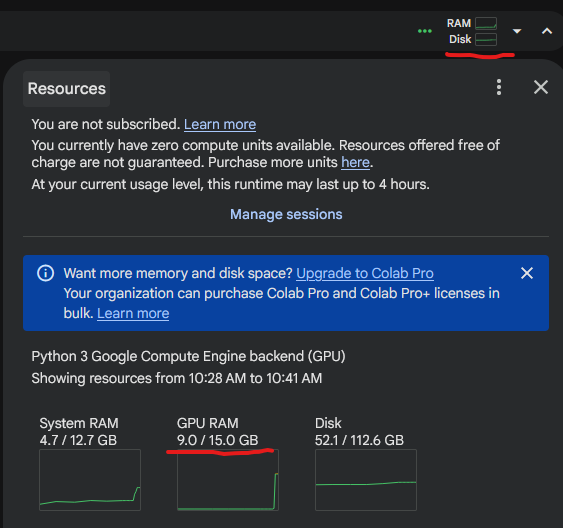

In [ ]:
# This will take at least 5 minutes to run
# Take the time to search/google/use AI to understand what each of the variables going into this function do
geoai.train_segmentation_model(
    images_dir=f"{tiles_dir}/images",
    labels_dir=f"{tiles_dir}/masks",
    output_dir=f"{tiles_dir}/unet_models",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=6,
    num_classes=2,
    batch_size=8,
    num_epochs=3,
    learning_rate=0.001,
    val_split=0.2,
    verbose=True,
)

print('Training complete!')

**Q2**: Explain why using U-Net and ResNet34 together is a good choice when working with multi-spectral imagery. Use at least two references in your response.

**Answer:**
U-Net and ResNet34 work well together because each solves a different part of the problem. ResNet34 acts as the encoder that extracts features, and U-Net's decoder and skip connections turn those features back into a pixel-level map.

ResNet34 (He et al., 2016) is built from residual blocks that add the input to the block's output, which lets a deep network train without the gradient fading. Its stages produce feature maps at several resolutions, and its ImageNet-pretrained weights already detect edges and textures. This reduces the training time and data needed (Iglovikov & Shvets, 2018). U-Net (Ronneberger et al., 2015) up-samples these features back to the input resolution. Skip connections copy the high-resolution encoder features into the matching decoder stage, so narrow rivers and small ponds keep sharp boundaries instead of being blurred by down-sampling.

This suits multispectral data because water has a distinctive spectral signature: it absorbs strongly in the NIR and SWIR and is therefore dark there, while vegetation and soil are bright. With six input channels (Blue, Green, Red, NIR, SWIR1, SWIR2), the network can learn its own weighted band combinations, similar to NDWI (McFeeters, 1996) or MNDWI (Xu, 2006) but without a fixed formula or threshold. Its spatial context, such as the shape and connectedness of a river, helps separate water from shadows, which also have low NIR/SWIR reflectance. One caveat is that the pretrained weights were learned from three-band photographs, so the NIR and SWIR channels depend more on fine-tuning.

**References**

•	He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. CVPR, 770-778.

•	Iglovikov, V., & Shvets, A. (2018). TernausNet: U-Net with VGG11 encoder pre-trained on ImageNet for image segmentation. arXiv:1801.05746.

•	McFeeters, S. K. (1996). The use of the Normalized Difference Water Index (NDWI) in the delineation of open water features. International Journal of Remote Sensing, 17(7), 1425-1432.

•	Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. MICCAI, LNCS 9351, 234-241.

•	Xu, H. (2006). Modification of normalised difference water index (NDWI) to enhance open water features in remotely sensed imagery. International Journal of Remote Sensing, 27(14), 3025-3033.

**Q3**: What is the learning_rate and what is the likely effect that reducing it will have on your model?

**Answer:** The learning rate (here 0.001) is the optimiser's step size: it controls how far each weight is adjusted along the negative gradient of the loss after every batch. A high rate makes large updates that can overshoot the minimum, while a low rate makes small, careful ones.

Reducing the learning rate would make training more stable and reduce the risk of overshooting or oscillating around the minimum. It would also help preserve the pretrained ResNet features instead of overwriting them. The trade-off is slower convergence. Because the model is trained for only 3 epochs, a much smaller rate would likely leave it under-trained, with higher loss and lower accuracy, unless the number of epochs was increased. Too small a rate can also cause training to stall on a plateau. In practice, the rate is often lowered gradually during training (for example, with a scheduler) while running more epochs. GeoAI's training function uses the Adam optimiser with a ReduceLROnPlateau scheduler, which halves the learning rate when validation loss stops improving for several epochs.

This model took me 4 to 6 minutes to run on the GPU. If it is taking you more than that, check that you are not still stuck using a CPU (it will take a LOT longer if on a CPU).

With one line of code, we can now take a look at the model performance:

In [ ]:
# Performance statistics
geoai.plot_performance_metrics(
    history_path=f"{tiles_dir}/unet_models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

**Q4**: Increase the number of training epochs to 10 (this will take some time, so maybe come back to this question later if need be). Present the resulting graphs of performance metrics in a figure and interpret the results for a technical audience (describe the training that has occured and make reccomendations for future training/use of the model). As always, figures should be of publication quality.

In [ ]:
# Takes roughly 15-20 min on a T4. Uses a NEW output folder so your 3-epoch results are kept.
# Q.4: Retrain the water model for 10 epochs (seperate output folder keeps the 3-epoch run for comparison)
geoai.train_segmentation_model(
    images_dir=f"{tiles_dir}/images",
    labels_dir=f"{tiles_dir}/masks",
    output_dir=f"{tiles_dir}/unet_models_10ep",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=6,
    num_classes=2,
    batch_size=8,
    num_epochs=10,          # the only change Q4 asks for
    learning_rate=0.001,
    val_split=0.2,
    verbose=True,
)
print("Training complete!")

In [ ]:
# Q.4: load both training histories and plot a publication-quality performance figure (Fig. 1)

import torch
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 12,
    "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
    "savefig.dpi": 300, "savefig.bbox": "tight",
})

# Names as stored in the file -> names used in the rest of the code
KEYMAP = {
    "train_losses":   "train_loss",
    "val_losses":     "val_loss",
    "val_ious":       "val_iou",
    "val_f1s":        "val_f1",
    "val_precisions": "val_precision",
    "val_recalls":    "val_recall",
}
KEYS = list(KEYMAP.values())


def load_history(path):
    h = torch.load(path, map_location="cpu", weights_only=False)
    missing = [k for k in KEYMAP if k not in h]
    if missing:
        raise KeyError(f"Missing {missing}. Keys found in file: {list(h.keys())}")
    df = pd.DataFrame({new: [float(x) for x in h[old]] for old, new in KEYMAP.items()})
    df.index = np.arange(1, len(df) + 1)
    df.index.name = "epoch"
    return df

hist10 = load_history(f"{tiles_dir}/unet_models_10ep/training_history.pth")
hist3 = load_history(f"{tiles_dir}/unet_models/training_history.pth")   # your earlier 3-epoch run
display(hist10.round(4))

# Colour-blind-safe palette (Okabe-Ito)
BLUE, RED, GREEN, PURPLE = "#0072B2", "#D55E00", "#009E73", "#CC79A7"

best = int(hist10["val_loss"].idxmin())          # epoch with lowest validation loss
epochs = hist10.index.values

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)

# (a) Loss
ax = axes[0]
ax.plot(epochs, hist10["train_loss"], "o-", color=BLUE, lw=2, ms=5, label="Training loss")
ax.plot(epochs, hist10["val_loss"], "s-", color=RED, lw=2, ms=5, label="Validation loss")
if hist10["val_loss"].max() / hist10["val_loss"].min() > 20:
    ax.set_yscale("log")                          # early validation loss can be orders of magnitude larger
ax.set_ylabel("Loss" + (" (log scale)" if ax.get_yscale() == "log" else ""))
ax.set_title("Loss", fontweight="bold")
ax.legend(frameon=False)

# (b) Overlap-based metrics
ax = axes[1]
ax.plot(epochs, hist10["val_iou"], "o-", color=BLUE, lw=2, ms=5, label="IoU")
ax.plot(epochs, hist10["val_f1"], "s-", color=GREEN, lw=2, ms=5, label="F1 score")
ax.set_ylabel("Score (0-1)")
ax.set_title("Validation IoU and F1", fontweight="bold")
ax.legend(frameon=False, loc="lower right")

# (c) Error-type metrics
ax = axes[2]
ax.plot(epochs, hist10["val_precision"], "o-", color=PURPLE, lw=2, ms=5, label="Precision")
ax.plot(epochs, hist10["val_recall"], "s-", color=RED, lw=2, ms=5, label="Recall")
ax.set_ylabel("Score (0-1)")
ax.set_title("Validation precision and recall", fontweight="bold")
ax.legend(frameon=False, loc="lower right")

for ax, letter in zip(axes, "abc"):
    ax.set_xlabel("Epoch")
    ax.set_xticks(epochs)
    ax.grid(alpha=0.3)
    ax.axvline(best, color="grey", ls="--", lw=1.2)                 # lowest validation loss/
    ax.text(-0.02, 1.04, f"({letter})", transform=ax.transAxes, ha="right", va="bottom",
        fontsize=14, fontweight="bold")
    # ax.text(0.03, 0.96, f"({letter})", transform=ax.transAxes, ha="left", va="top",
            # fontsize=14, fontweight="bold")
axes[0].annotate(f"lowest val. loss\n(epoch {best})", xy=(best, hist10.loc[best, "val_loss"]),
                 xytext=(0.5, 0.55), textcoords="axes fraction", fontsize=10, ha="center",
                 arrowprops=dict(arrowstyle="->", color="grey"))

fig.savefig("fig1_training_10_epochs.png")
fig.savefig("fig1_training_10_epochs.pdf")
plt.show()

**Figure 1. Training and validation performance of the U-Net/ResNet34 water-segmentation model over 10 epochs (six Sentinel-2 bands, batch size 8, learning rate 0.001, 80/20 tile split): (a) training and validation loss (log scale); (b) validation IoU and F1; (c) validation precision and recall. The dashed line marks the epoch with the lowest validation loss.**

**Answer:** The model was trained for 10 epochs(Fig. 1). Training loss declined gradually from 0.375 to 0.292. Validation loss fell from 11.1 to 0.098 by epoch 3 but then fluctuated (0.68 at epoch 4, 0.16 at epoch 6), reaching its minimum of 0.081 at epoch 5. Validation IoU and F1 also peaked at epoch 5 (0.871 and 0.913) and then oscillated without improving (IoU 0.735 to 0.868), so the model had plateaued by about epoch 5. The curves do not show classic overfitting, because validation loss did not rise steadily while training loss fell. The instability was mainly in recall (0.82 to 0.93) rather than precision (0.87 to 0.94), meaning the amount of water the model missed varied between epochs. Compared with the 3-epoch model (IoU 0.837, F1 0.890), training longer gave at most a modest gain, and only at the best checkpoint.

**Recommendations:** Use early stopping on validation loss and keep the best checkpoint (epoch 5) instead of the final weights. Use a more responsive learning-rate schedule (cosine decay, or reduce-on-plateau with a shorter patience), because GeoAI's built-in scheduler (patience 5) could not trigger within 10 epochs, to damp the late oscillation. Add data augmentation (flips, rotations, brightness jitter) and an imbalance-aware loss such as Dice, since water is the minority class and recall is the unstable metric. Split training and validation by scene, not by tile: tiles overlap by 50%, so a random split leaks near-duplicate pixels into validation and these scores are probably optimistic. Finally, judge the model on the independent validation scenes and report IoU, F1, precision and recall for the water class.

In addition to these performance statistics, we can run [inference](https://www.cloudflare.com/learning/ai/inference-vs-training/) on the validation set to evaluate the model's performance. We will use the semantic_segmentation_batch function to process all the validation images at once.

In [ ]:
images_dir = f"{data_dir}/dset-s2/val_scene"
masks_dir = f"{data_dir}/dset-s2/val_truth"
predictions_dir = f"{data_dir}/dset-s2/predictions"
model_path = f"{tiles_dir}/unet_models/best_model.pth"

In [ ]:
geoai.semantic_segmentation_batch(
    input_dir=images_dir,
    output_dir=predictions_dir,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=6,
    num_classes=2,
    window_size=512,
    overlap=128,
    batch_size=4,
    quiet=True,
)

And then visualize the results of this!

In [ ]:
# Visualize inference outcomes

image_id = "S2A_L2A_20190318_N0211_R061"  # Change to other image id, e.g., S2B_L2A_20190620_N0212_R047
test_image_path = f"{data_dir}/dset-s2/val_scene/{image_id}_6Bands_S2.tif"
ground_truth_path = f"{data_dir}/dset-s2/val_truth/{image_id}_S2_Truth.tif"
prediction_path = f"{data_dir}/dset-s2/predictions/{image_id}_6Bands_S2_mask.tif"
save_path = f"{data_dir}/dset-s2/{image_id}_6Bands_S2_comparison.png"

fig = geoai.plot_prediction_comparison(
    original_image=test_image_path,
    prediction_image=prediction_path,
    ground_truth_image=ground_truth_path,
    titles=["Original", "Prediction", "Ground Truth"],
    figsize=(15, 5),
    save_path=save_path,
    show_plot=True,
    indexes=[5, 4, 3],
    divider=5000,
)

In [ ]:
# EXTRA (Q5): annotated comparison of the prediction against ground truth for the validation scene, with an error map

import numpy as np, rasterio, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D

image_id = "S2A_L2A_20190318_N0211_R061"
img_p = f"{data_dir}/dset-s2/val_scene/{image_id}_6Bands_S2.tif"
gt_p  = f"{data_dir}/dset-s2/val_truth/{image_id}_S2_Truth.tif"
pr_p  = f"{data_dir}/dset-s2/predictions/{image_id}_6Bands_S2_mask.tif"

def q5_read(path, bands):
    with rasterio.open(path) as s:
        return (s.read(bands, masked=True).astype("float32"),
                [s.bounds.left, s.bounds.right, s.bounds.bottom, s.bounds.top], s.crs)

def q5_rgb(a):
    out = []
    for b in np.ma.filled(a, np.nan):
        lo, hi = np.nanpercentile(b, (2, 98))
        out.append(np.clip((b - lo) / max(hi - lo, 1e-6), 0, 1))
    return np.nan_to_num(np.dstack(out))

natural, ext, crs = q5_read(img_p, [3, 2, 1]); natural = q5_rgb(natural)      # B4-B3-B2
falsec = q5_rgb(q5_read(img_p, [5, 4, 3])[0])                                  # SWIR1-NIR-Red (water = dark)
gt = np.ma.filled(q5_read(gt_p, [1])[0][0], 0) > 0
pr = np.ma.filled(q5_read(pr_p, [1])[0][0], 0) > 0
assert gt.shape == pr.shape == natural.shape[:2], "image, truth and prediction are on different grids"
print(f"Water fraction: ground truth {gt.mean():.1%}, prediction {pr.mean():.1%}")

TP, FP, FN = gt & pr, ~gt & pr, gt & ~pr
prec = TP.sum() / max(TP.sum() + FP.sum(), 1); rec = TP.sum() / max(TP.sum() + FN.sum(), 1)
iou = TP.sum() / max(TP.sum() + FP.sum() + FN.sum(), 1); f1 = 2 * prec * rec / max(prec + rec, 1e-9)
print(f"Water IoU = {iou:.3f} | F1 = {f1:.3f} | precision = {prec:.3f} | recall = {rec:.3f}")

err = np.full(gt.shape + (3,), 0.93)
err[TP] = (0.12, 0.47, 0.71); err[FP] = (0.84, 0.15, 0.16); err[FN] = (1.0, 0.65, 0.0)

def q5_decor(ax, ext, crs, length_m=1000):
    mpu = crs.linear_units_factor[1] if crs.is_projected else 111320
    L = length_m / mpu; w, h = ext[1] - ext[0], ext[3] - ext[2]
    x0, y0, bh = ext[0] + 0.04 * w, ext[2] + 0.05 * h, 0.012 * h
    ax.add_patch(Rectangle((x0 - 0.01 * w, y0 - 2 * bh), L + 0.1 * w, 7 * bh, fc="white", alpha=0.85, zorder=6))
    ax.add_patch(Rectangle((x0, y0), L / 2, bh, fc="k", ec="k", zorder=7))
    ax.add_patch(Rectangle((x0 + L / 2, y0), L / 2, bh, fc="w", ec="k", zorder=7))
    ax.text(x0, y0 + 1.9 * bh, "0", ha="center", fontsize=10, zorder=8)
    ax.text(x0 + L, y0 + 1.9 * bh, "1 km", ha="center", fontsize=10, zorder=8)
    ax.annotate("", xy=(0.94, 0.92), xytext=(0.94, 0.80), xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", lw=2.2, color="k", mutation_scale=20), zorder=8)
    ax.text(0.94, 0.93, "N", transform=ax.transAxes, ha="center", fontsize=14, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8), zorder=8)

fig, axes = plt.subplots(2, 2, figsize=(13, 11), constrained_layout=True, sharex=True, sharey=True)
titles = ["Natural colour (B4-B3-B2)", "False colour (SWIR1-NIR-Red)", "Prediction vs ground truth", "Error map"]
for ax, t, letter in zip(axes.ravel(), titles, "abcd"):
    im = {"a": natural, "b": falsec, "c": falsec, "d": err}[letter]
    ax.imshow(im, extent=ext, origin="upper")
    if letter == "c":
        ax.imshow(np.ma.masked_where(~pr, pr), extent=ext, origin="upper",
                  cmap=mpl.colors.ListedColormap(["#00e5ff"]), alpha=0.6)
        ax.contour(gt.astype(float), levels=[0.5], extent=ext, origin="upper", colors="yellow", linewidths=0.8)
    ax.set_title(t, fontweight="bold"); ax.ticklabel_format(useOffset=False, style="plain")
    ax.tick_params(axis="x", rotation=30); ax.set_aspect("equal")
    ax.text(0.02, 0.97, f"({letter})", transform=ax.transAxes, ha="left", va="top", fontsize=15, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85), zorder=9)
    q5_decor(ax, ext, crs)
for ax in axes[1]: ax.set_xlabel("Easting (m)")
for ax in axes[:, 0]: ax.set_ylabel("Northing (m)")
axes[1, 0].legend(handles=[Patch(fc="#00e5ff", alpha=0.6, label="Predicted water"),
                           Line2D([0], [0], color="yellow", lw=1.5, label="Ground-truth water edge")],
                  loc="lower right", framealpha=0.92)
axes[1, 1].legend(handles=[Patch(fc=(0.12, 0.47, 0.71), label="True positive"),
                           Patch(fc=(0.84, 0.15, 0.16), label="False positive (commission)"),
                           Patch(fc=(1.0, 0.65, 0.0), label="False negative (omission)"),
                           Patch(fc=(0.93, 0.93, 0.93), label="True negative")],
                  loc="lower right", framealpha=0.92)
fig.savefig("fig_Q5_validation_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

**Figure 2. Validation scene S2A_L2A_20190318_N0211_R061 (3-epoch model): (a) natural colour; (b) false colour (SWIR1-NIR-Red), where water is dark; (c) predicted water (cyan) with the ground-truth water edge (yellow); (d) error map. Panels share the same extent. Water IoU = 0.629, F1 = 0.772, precision = 0.706, recall = 0.852.**

**Q5**: Discuss the performance of the prediction in our example given above. Do so in reference to the ability of the prediction to resolve key features as compared to the ground truth (e.g. the river vs. the flood ponds). Explain why perfomance is varying in terms of both satellite data physical principles and the limitations of model and its training.

**Answer:** For this scene the water IoU is 0.629, F1 0.772, precision 0.706 and recall 0.852 (Fig. 2). Water covers 7.3% of the scene in the ground truth but 8.8% in the prediction, so the model over-predicts water: the errors are mostly false positives (commission), with fewer omissions.

The model resolves the large, continuous features best. The main river is traced as a continuous channel, with a thin fringe of missed pixels along its banks, and the thinner river in the upper right is only partly captured. The extent of the large lake in the upper left is reproduced, but the prediction fills in the strips of land between its ponds, which the ground truth leaves as non-water, giving the red patches inside the lake. Small water bodies are inconsistent: many flood ponds are detected, but several isolated blobs are predicted where the ground truth has no water, and a few small ponds are missed.

Satellite physics explains much of this. Water absorbs strongly in the NIR and SWIR, so open water is very dark in the SWIR1-NIR-Red composite (Fig. 2b) and is easy to separate. The strips between ponds and the river banks are narrower than a few 10 m pixels, so they are mixed pixels (water plus soil or vegetation), whose NIR/SWIR reflectance is intermediate and easily assigned to the wrong class. Dark surfaces that are not water, such as shadows and wet or dark soils, also have low NIR/SWIR reflectance and cause the isolated false positives. The SWIR bands are natively 20 m and resampled to 10 m, so they add no true 10 m detail, and turbid or shallow water is lighter than clear water, which makes it a weaker match for typical training examples.

Model and training limitations add to this. The prediction was made with the 3-epoch model, which was still improving when training stopped (validation IoU 0.837 and F1 0.890 at epoch 3, Q4), so it is under-trained. The much lower scene IoU (0.629) shows that the tile-based validation was optimistic: tiles overlap by 50%, so validation tiles share pixels with training tiles, and the model has not seen this scene. Water is the minority class, so errors on small features cost little in the loss, the encoder was pretrained on three-band photographs, so the NIR/SWIR channels had little opportunity to adapt, and repeated down-sampling in the 512 px tiles blurs thin features. The ground-truth labels themselves may be uncertain along narrow boundaries. Improvements would include longer training with a more responsive learning-rate schedule, augmentation, a Dice or focal loss, a scene-level validation split, and more varied training scenes.

Hopefully you can now see the difference that GeoAI makes to your workflow as compared to what we have gone through in the other labs.

Their library is doing a lot of the plumbing and model management for you behind the scenes, allowing you to write faster and solve different problems rather than getting stuck in the weeds. We have only imported one library to accomplish something that before we were using 5 or 6 to do. This does come with drawbacks, choices have been made for you- but particuarly for quick prototyping this is a strong advantage.

Note that the GeoAI tutorial also shows you [how to gather satellite data](https://opengeoai.org/workshops/TNView_2025/#download-sentinel-2-imagery) from a [STAC catalgoue](https://stacspec.org/en). This is the alternative (to the GEE approach used to date) way to build satellite data stacks for use in your project. Might well be useful for you in your projects...

# Task 2: Detecting solar panels from aerial imagery
In Task 1 we used semantic segmentation to classify pixels in satellite imagery. In this task we use a similar deep-learning workflow to identify solar panels in high-resolution aerial imagery, but then move from pixels to individual mapped objects.

The important distinction is that the U-Net produces a pixel-level segmentation. We will then convert that segmentation into polygons and use the geometry of those polygons to remove some of the small or implausible detections. This gives us a simple object-level workflow without introducing a separate object-detection model.

Before starting this task, clear the cache and make sure your RAM is empty from Task 1, or you may crash the Colab instance.

We will work with a labelled training image and vector dataset from Davis, California, and a separate aerial image for testing. The data are provided through [Hugging Face](https://huggingface.co/).

First, we will clear the data and model from Task 1 from our memory. You always want to make sure that a fresh model run has a clean memory to use, as otherwise these free instances will very quickly beocome jammed up and crash:

In [ ]:
# Clear memory before starting Task 2
import gc

# Python garbage collection
gc.collect()

# Clear PyTorch GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# Report current GPU memory
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3

    print("Memory cleared.")
    print(f"GPU memory allocated: {allocated:.2f} GB")
    print(f"GPU memory reserved:  {reserved:.2f} GB")
else:
    print("Memory cleared. No CUDA GPU detected.")

Next, we specify our data sources and then download them:

In [ ]:
# Set the URLS that you are getting the data from
train_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.tif"
train_vector_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_davis_ca.geojson"
test_raster_url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/solar_panels_test_davis_ca.tif"

In [ ]:
# Use GeoAI to download them
train_raster_path = geoai.download_file(train_raster_url)
train_vector_path = geoai.download_file(train_vector_url)
test_raster_path = geoai.download_file(test_raster_url)

Let's take a look at it using our own interactive view tool.

In [ ]:
show_interactive(raster=train_raster_path, vector=train_vector_path, title="Training scene")

Q6: Examine the training image and labelled polygons. What visual characteristics distinguish the solar panels from the surrounding roofs, roads and vegetation? Identify at least two characteristics that a convolutional neural network could potentially learn from the imagery.

**Answer:** Comparing the aerial image with and without the labelled polygons, solar panels are distinguished from roofs, roads and vegetation by four main characteristics.

**Tone and colour:** Panels are dark navy to mid-blue, depending on sun angle, and are fairly uniform within an array. Roofs are lighter and more varied (terracotta, brown shingle, grey, white and slate blue), roads are mid-grey asphalt, and vegetation is green with deep shadows.

**Texture:** Panels show a regular grid of thin pale lines where cells and modules meet, producing a repeating, high-contrast pattern. Roofs are smoother or have a coarser shingle texture, roads are smooth, and tree canopies are irregular and speckled.

**Shape and geometry:** Panels form compact blocks made of rectangles with straight edges and right-angled corners, usually aligned with the roof edges and arranged in parallel rows (some arrays are stepped or L-shaped). Roads are long thin strips, trees have rounded irregular outlines, and swimming pools have smooth curved outlines.

**Context:** The labelled panels all sit on rooftops, so neighbouring building edges and roof planes give supporting evidence.

A convolutional neural network could learn at least the first three. Its early layers learn colour contrast and edges, which capture the dark tone and sharp boundaries. Its middle layers combine these into texture detectors for the repeated cell grid, and its deeper layers, with larger receptive fields, represent block shape and rooftop context. No single cue is enough, because some surfaces share one of them: slate-blue roofs resemble panels in colour, dark pools and tree shadows resemble them in tone, and dark shingle roofs are similar in brightness. The network therefore has to combine tone, texture and shape, and these look-alikes are the likely sources of error when the model is applied to new imagery.

We now convert the labelled image into image/label tiles for training.

A 512 × 512 tile is large enough to contain complete solar-panel objects while still being manageable on a Colab GPU. The stride controls how much neighbouring tiles overlap.

In [ ]:
out_folder = "solar"
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,
    out_folder=out_folder,
    in_class_data=train_vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
)

Train a U-Net segmentation model. As in Task 1, the model predicts a class for each pixel. Here the two classes are background and solar panel. This took me 3-5 minutes to train on the GPU. On the CPU it took over 30 minutes:

In [ ]:
geoai.train_segmentation_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/models",
    architecture="unet",
    encoder_name="resnet34",
    encoder_weights="imagenet",
    num_channels=3,
    num_classes=2,
    batch_size=8,
    num_epochs=10,
    learning_rate=1e-3,
    val_split=0.2,
)

Evaluate the model:

In [ ]:
geoai.plot_performance_metrics(
    history_path=f"{out_folder}/models/training_history.pth",
    figsize=(15, 5),
    verbose=True,
)

**Figure 3. Training and validation loss, IoU, F1, precision and recall of the solar-panel U-Net over 10 epochs.**

In [ ]:
# EXTRA (Q7): check whether GeoAI's training function applies a learning-rate scheduler

import inspect
code = inspect.getsource(geoai.train_segmentation_model)
print([l.strip() for l in code.splitlines() if any(k in l.lower() for k in ("scheduler", "optim", "lr"))][:15])

Q7: Examine the training and validation curves. Is there evidence that the model is still learning, or that it is beginning to overfit? What would you change about the training process if you wanted to improve the model further?

**Answer:** The curves show no evidence of overfitting, and the model is close to, but not fully, converged. Training loss fell from 0.117 to 0.019 over the 10 epochs, with most of the drop in the first two epochs and a slow decline afterwards. Validation loss followed it closely, falling from 0.062 to a minimum of 0.0175 at epoch 8 and ending at 0.0197, almost the same as the final training loss (0.0189). Because validation loss never rose steadily while training loss fell, and the gap between them is negligible, the model is not memorising the training tiles. Validation IoU and F1 improved to a peak at epoch 8 (IoU 0.857, F1 0.881) and then levelled off (IoU 0.855 and 0.851), suggesting that gains from further training at this setting would be small.

The curves are, however, noisy. Validation loss spiked at epochs 6 and 7, IoU fell to 0.731 at epoch 5, and precision (0.79 to 0.99) and recall (0.78 to 0.89) fluctuated strongly. This suggests the learning rate (Adam, 0.001) is too large in the later epochs. GeoAI applies a ReduceLROnPlateau scheduler (factor 0.5, patience 5), but because validation loss never stalled for five consecutive epochs in this ten-epoch run, the rate was probably never reduced, so the weights kept bouncing around the minimum rather than settling. Precision was generally higher than recall (0.94 vs 0.88 at epoch 10), so the model tends to miss some panels rather than over-detect them.

**To improve the model I would:**

(1) use a more responsive learning-rate schedule (cosine decay, or reduce-on-plateau with a shorter patience of about 2 epochs, since the default patience of 5 cannot trigger within 10 epochs) and train for more epochs to reduce the oscillation;

(2) apply data augmentation (flips, rotations, brightness and colour jitter) to improve generalisation;

(3) add more varied training imagery (other neighbourhoods, roof types, sun angles), because a single image from one area limits what the model can learn;

(4) use a Dice or focal loss to handle the strong class imbalance, since panels cover a small fraction of pixels, which should also raise recall;

(5) split the training and validation tiles by area rather than randomly, since tiles overlap by 50% and neighbouring tiles leak near-duplicate pixels into validation, so these scores are probably optimistic and the unseen test image is the real check; and

(6) keep the best checkpoint (epoch 8) rather than the final weights.

Now apply the trained model to the unseen test image. In addition to the usual class mask, we will save the model's probability map. For a two-class problem, the second band contains the probability that each pixel belongs to the solar-panel class.

This is useful because the default mask hides how confident the model was. A pixel just above the classification boundary is different from a pixel for which the model is highly confident.

In [ ]:
masks_path = "solar_panels_prediction.tif"
probability_path = "solar_panels_probability.tif"
model_path = f"{out_folder}/models/best_model.pth"

geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=masks_path,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=8,
    probability_path=probability_path,
)

Let's look at both the predicted mask.

In [ ]:
show_interactive(raster=test_raster_path, mask=masks_path, probability=probability_path, title="Predictions")

In [ ]:
# EXTRA (Q8 setup): helper functions for reading raster windows, plus a whole-scene grid used to choose zoom areas

import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds, bounds as win_bounds
from rasterio.enums import Resampling
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb      # restores the lab's version

mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 12, "axes.titlesize": 13,
    "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 11, "savefig.dpi": 300, "savefig.bbox": "tight",
})


def read_window(path, bands, zoom, max_px=1800, resampling=Resampling.bilinear):
    """Read part of a raster. zoom = (x0, y0, x1, y1) as FRACTIONS of the scene, measured from the TOP-LEFT."""
    with rasterio.open(path) as src:
        L, B, R, T = src.bounds
        x0, y0, x1, y1 = zoom
        b = (L + x0 * (R - L), T - y1 * (T - B), L + x1 * (R - L), T - y0 * (T - B))
        win = from_bounds(*b, transform=src.transform)
        s = min(1.0, max_px / max(win.width, win.height))
        shape = (len(bands), max(1, int(win.height * s)), max(1, int(win.width * s)))
        arr = src.read(bands, window=win, out_shape=shape, resampling=resampling, masked=True)
        wb = win_bounds(win, src.transform)
        return arr, [wb[0], wb[2], wb[1], wb[3]], src.crs, src.dtypes[0]


def image_to_rgb(arr, dtype):
    a = np.moveaxis(np.ma.filled(arr.astype("float32"), 0), 0, -1)
    if dtype == "uint8":
        return np.clip(a / 255.0, 0, 1)
    lo, hi = np.percentile(a, (2, 98))
    return np.clip((a - lo) / max(hi - lo, 1e-6), 0, 1)


# ---- PREVIEW: whole scene with a 0-1 grid so you can choose zoom windows ----
with rasterio.open(test_raster_path) as src:
    s = min(1.0, 1500 / max(src.width, src.height))
    prev = src.read([1, 2, 3], out_shape=(3, int(src.height * s), int(src.width * s)),
                    resampling=Resampling.bilinear, masked=True)
    prev_dtype = src.dtypes[0]
fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(image_to_rgb(prev, prev_dtype), extent=(0, 1, 1, 0))
ax.set_xticks(np.arange(0, 1.01, 0.1)); ax.set_yticks(np.arange(0, 1.01, 0.1))
ax.grid(color="yellow", alpha=0.6, lw=0.8)
ax.set_xlabel("x fraction (left to right)"); ax.set_ylabel("y fraction (top to bottom)")
ax.set_title("Pick two windows: (x0, y0, x1, y1)")
plt.show()

In [ ]:
# EXTRA (Q8 setup): check the two zoom windows (A and B) before plotting

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.imshow(image_to_rgb(prev, prev_dtype), extent=(0, 1, 1, 0))
for name, (x0, y0, x1, y1), col in [("A", (0.00, 0.00, 0.62, 0.52), "red"),
                                    ("B", (0.08, 0.50, 0.72, 1.00), "cyan")]:
    ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fc="none", ec=col, lw=2.5))
    ax.text(x0 + 0.01, y0 + 0.04, name, color=col, fontsize=16, fontweight="bold")
ax.set_xlabel("x fraction"); ax.set_ylabel("y fraction")
plt.show()

In [ ]:
# EXTRA (Q8-Q13 helper): scale bar and area factor corrected for Web Mercator distortion

def ground_factor(crs, ext):
    """Ground metres per map unit. EPSG:3857 stretches distances by 1/cos(latitude)."""
    if crs is not None and crs.to_epsg() == 3857:
        lat = np.degrees(2 * np.arctan(np.exp(((ext[2] + ext[3]) / 2) / 6378137.0)) - np.pi / 2)
        return float(np.cos(np.radians(lat)))
    if crs is not None and crs.is_projected:
        return float(crs.linear_units_factor[1])
    return 111320 * np.cos(np.deg2rad((ext[2] + ext[3]) / 2))


def add_scalebar(ax, ext, crs, length_m):
    L = length_m / ground_factor(crs, ext)
    w, hh = ext[1] - ext[0], ext[3] - ext[2]
    x0, y0, h = ext[0] + 0.04 * w, ext[2] + 0.05 * hh, 0.013 * hh
    ax.add_patch(Rectangle((x0 - 0.012 * w, y0 - 2 * h), L + 0.085 * w, 7.5 * h, fc="white", alpha=0.85, zorder=6))
    ax.add_patch(Rectangle((x0, y0), L / 2, h, fc="k", ec="k", zorder=7))
    ax.add_patch(Rectangle((x0 + L / 2, y0), L / 2, h, fc="w", ec="k", zorder=7))
    ax.text(x0, y0 + 1.9 * h, "0", ha="center", fontsize=10, zorder=8)
    ax.text(x0 + L, y0 + 1.9 * h, f"{length_m:g} m", ha="center", fontsize=10, zorder=8)

In [ ]:
# Q8: binary mask vs probability map for two zoomed areas, with numbered markers and a probability table (Fig. 4)

ZOOMS = {
    "A": (0.00, 0.00, 0.62, 0.52),   # cul-de-sac scene
    "B": (0.08, 0.50, 0.72, 1.00),   # park / court scene
}
SCALE_M = 10

# (scene, number, fx, fy, description)   fx = from LEFT of the window, fy = from BOTTOM (both 0-1)
MARKERS = [
    ("A", 1, 0.40, 0.88, "Confident array (grey roof, head of cul-de-sac)"),
    ("A", 2, 0.61, 0.42, "Dark panels on dark grey roof (missed)"),
    ("B", 3, 0.17, 0.55, "Basketball-court markings (look-alike)"),
    ("B", 4, 0.83, 0.92, "Dark panel on grey roof (weak response)"),
    ("B", 5, 0.75, 0.68, "Swimming pool (should be empty)"),
]
ARROW_OFFSET = (0.07, -0.10)   # where each number sits relative to its feature (axes fraction)

def add_north_arrow(ax):
    ax.annotate("", xy=(0.95, 0.91), xytext=(0.95, 0.74), xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", lw=2.2, color="k", mutation_scale=20), zorder=8)
    ax.text(0.95, 0.925, "N", transform=ax.transAxes, ha="center", va="bottom", fontsize=14, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8), zorder=8)


def add_marker(ax, n, fx, fy):
    ax.annotate(str(n), xy=(fx, fy), xytext=(fx + ARROW_OFFSET[0], fy + ARROW_OFFSET[1]),
                xycoords="axes fraction", textcoords="axes fraction", ha="center", va="center",
                fontsize=12, fontweight="bold", color="black", zorder=9,
                bbox=dict(boxstyle="circle,pad=0.25", fc="white", ec="black", lw=1.2),
                arrowprops=dict(arrowstyle="-|>", color="#ffe600", lw=2,
                                path_effects=[pe.withStroke(linewidth=4, foreground="black")],
                                shrinkA=8, shrinkB=0))


fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), constrained_layout=True)
CYAN = "#39ff14"
stats, crs_used = [], None
im = None

for r, (key, zoom) in enumerate(ZOOMS.items()):
    rgb_a, ext, crs, dt = read_window(test_raster_path, [1, 2, 3], zoom)
    rgb = image_to_rgb(rgb_a, dt)
    mask = np.ma.filled(read_window(masks_path, [1], zoom, resampling=Resampling.nearest)[0][0], 0) > 0
    prob = np.ma.filled(read_window(probability_path, [2], zoom)[0][0].astype("float32"), 0)
    if prob.max() > 1.5:                       # stored as 0-255 or 0-100
        prob = prob / (255.0 if prob.max() > 100 else 100.0)
    crs_used = crs

    axm, axp = axes[r, 0], axes[r, 1]
    for ax in (axm, axp):
        ax.imshow(rgb, extent=ext, origin="upper")

    axm.imshow(np.ma.masked_where(~mask, mask), extent=ext, origin="upper",
               cmap=mpl.colors.ListedColormap([CYAN]), alpha=0.75)
    im = axp.imshow(np.ma.masked_less(prob, 0.05), extent=ext, origin="upper",
                    cmap="magma", vmin=0, vmax=1, alpha=0.88)
    if mask.any():
        axp.contour(mask.astype(float), levels=[0.5], extent=ext, origin="upper", colors=CYAN, linewidths=1.3)

    letters = ("ab", "cd")[r]
    for ax, letter, title in [(axm, letters[0], "Binary mask"), (axp, letters[1], "Probability map")]:
        ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_aspect("equal")
        ax.set_title(title, fontweight="bold")
        ax.ticklabel_format(useOffset=False, style="plain")
        ax.tick_params(axis="x", rotation=30)
        ax.text(0.02, 0.97, f"({letter})", transform=ax.transAxes, ha="left", va="top", fontsize=15,
                fontweight="bold", bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85), zorder=9)
        add_scalebar(ax, ext, crs, SCALE_M)
        add_north_arrow(ax)
        if r == 1:
            ax.set_xlabel("Easting (m)" if crs.is_projected else "Longitude (deg)")
    axm.set_ylabel("Northing (m)" if crs.is_projected else "Latitude (deg)")
    axp.set_yticklabels([])

    for (k, n, fx, fy, desc) in MARKERS:
        if k != key:
            continue
        add_marker(axm, n, fx, fy); add_marker(axp, n, fx, fy)
        h, w = prob.shape
        r0, r1 = int(max(0, (1 - fy - 0.03) * h)), int(min(h, (1 - fy + 0.03) * h) + 1)
        c0, c1 = int(max(0, (fx - 0.03) * w)), int(min(w, (fx + 0.03) * w) + 1)
        box = prob[r0:r1, c0:c1]
        stats.append((n, desc, round(float(box.max()), 2), round(float(box.mean()), 2), bool(mask[r0:r1, c0:c1].any())))

axes[0, 0].legend(handles=[Patch(fc=CYAN, alpha=0.75, label="Predicted solar panel (class mask)")],
                  loc="lower right", framealpha=0.92)
axes[0, 1].legend(handles=[Line2D([0], [0], color=CYAN, lw=2, label="Outline of class mask")],
                  loc="lower right", framealpha=0.92)
cb = fig.colorbar(im, ax=axes[:, 1], fraction=0.035, pad=0.02)
cb.set_label("Probability of solar-panel class (values < 0.05 not shown)")

fig.savefig("fig_Q8_mask_vs_probability.png")
fig.savefig("fig_Q8_mask_vs_probability.pdf")
plt.show()

print("CRS for the caption:", crs_used)
display(pd.DataFrame(stats, columns=["marker", "feature", "max_prob_near_marker", "mean_prob_near_marker",
                                     "in_class_mask"]).set_index("marker"))

**Figure 4. Model output for two areas of the unseen test image: a cul-de-sac (a, b) and a park edge (c, d). Left panels show the binary mask (lime); right panels show the probability of the solar-panel class (magma scale; values below 0.05 not shown) with the mask outline in lime. Numbered arrows: (1) high-confidence array; (2) dark panels on a dark roof with almost no probability; (3) court markings with mid-range probability; (4) dark panel with low probability, not detected; (5) swimming pool with low probability. CRS: EPSG:3857; scale bar shows ground distance.**

Q8: Compare the binary mask with the probability map. Where does the model appear confident? Where does it appear uncertain? Why might a probability map be more useful than a binary mask when deciding how to improve a detection workflow?

**Answer:** The binary mask records only the model's final decision (panel or not panel, equivalent to a probability of about 0.5), while the probability map shows how confident the model was at every pixel. The two agree over the large, high-contrast arrays on lighter roofs. For example, the array on the grey roof at the head of the cul-de-sac (Fig. 4, marker 1) reaches a probability of 1.00 and is solid in the mask. Around each such core the probability fades through magenta and purple towards the edges, so the outline of a detection depends on where the cut-off is placed. The model is also confident about non-panel surfaces: the park grass and the roads have almost no probability, and swimming pools have low values (marker 5: maximum 0.37, mean 0.01), below the cut-off and therefore not detected.

The model is uncertain in two situations. First, on look-alike surfaces: the markings on the basketball court (marker 3) reach 0.46, just below the 0.5 cut-off, so most of them are not detected, although a short segment of line marking is detected elsewhere on the court. Second, on dark panels on dark roofs, where the model responds in two different ways. A dark panel on a grey roof (marker 4) reaches only 0.36 and is not detected, so it is "nearly detected". By contrast, the large array on the dark grey roof in the cul-de-sac scene (marker 2) has a maximum of 0.03, so the model does not recognise it at all. A likely reason is the low tonal contrast between black panels and dark roofs, unlike the high-contrast blue panels on light roofs that make up the confident detections.

The probability map is more useful than the binary mask for improving a detection workflow, for four reasons. First, the mask hides confidence: a pixel at 0.51 looks the same as one at 0.99, whereas the map lets you choose a threshold that trades false positives against omissions without retraining. Second, it tells you whether a miss can be fixed by a threshold. Lowering the threshold to 0.3 would recover marker 4 (0.36), but it would also admit the court (0.46) and the pool (0.37), so the threshold cannot solve it, and marker 2 (0.03) cannot be recovered at all, so both need more training examples of dark panels. Third, the probabilities can be summarised per detected object, to rank or filter detections and to decide where manual review is needed. Fourth, they help separate a boundary problem (low probability only at the edges of an array) from a gap in the training data (low probability across a whole roof type).

Improving the segmentation with a probability threshold:

The default binary result uses the model's class decision. We can instead specify a probability threshold for the solar-panel class. A lower threshold will normally retain more candidate pixels, while a higher threshold will normally produce fewer, more conservative detections.

Run the model again using a threshold of 0.7. Then compare this result with the original prediction.

In [ ]:
# Q9: run the lab's 0.7 threshold; the map shows the thresholded mask (edited from the lab cell)

threshold = 0.7
threshold_mask_path = f"solar_panels_prediction_{threshold:.1f}.tif"

geoai.semantic_segmentation(
    input_path=test_raster_path,
    output_path=threshold_mask_path,
    model_path=model_path,
    architecture="unet",
    encoder_name="resnet34",
    num_channels=3,
    num_classes=2,
    window_size=512,
    overlap=256,
    batch_size=8,
    probability_threshold=threshold,
)

show_interactive(raster=test_raster_path, mask=threshold_mask_path, probability=probability_path, title="Predictions")

Q9: Experiment with at least two different probability thresholds between 0.3 and 0.9. Compare the resulting masks visually. Which threshold gives you the most useful balance between retaining solar-panel pixels and rejecting false positives? Explain your choice using evidence from the imagery.

In [ ]:
# Q9: compare thresholds 0.3, default (~0.5), 0.7 and 0.9: figures, mapped-area table and marker table (Figs. 5-6)
import os
from matplotlib.colors import to_rgb          # make sure the lab's function is the active one

# ---- 1. Run the two extra thresholds (about 10 s each). Does NOT touch `threshold` / `threshold_mask_path` ----
extra = {}
for th in [0.3, 0.9]:
    out = f"solar_panels_prediction_{th:.1f}.tif"
    if not os.path.exists(out):
        geoai.semantic_segmentation(
            input_path=test_raster_path, output_path=out, model_path=model_path,
            architecture="unet", encoder_name="resnet34", num_channels=3, num_classes=2,
            window_size=512, overlap=256, batch_size=8, probability_threshold=th)
    extra[th] = out

TH_RUNS = [("Default class decision (~0.5)", masks_path),
           ("Threshold 0.3", extra[0.3]),
           ("Threshold 0.7", threshold_mask_path),
           ("Threshold 0.9", extra[0.9])]


# ---- 2. Figure: same window, four thresholds ----
def threshold_figure(key, filename):
    zoom = ZOOMS[key]
    rgb_a, ext, crs, dt = read_window(test_raster_path, [1, 2, 3], zoom)
    rgb = image_to_rgb(rgb_a, dt)
    fig, axes = plt.subplots(2, 2, figsize=(14, 8.8), constrained_layout=True, sharex=True, sharey=True)
    for ax, (label, path), letter in zip(axes.ravel(), TH_RUNS, "abcd"):
        m = np.ma.filled(read_window(path, [1], zoom, resampling=Resampling.nearest)[0][0], 0) > 0
        ax.imshow(rgb, extent=ext, origin="upper")
        ax.imshow(np.ma.masked_where(~m, m), extent=ext, origin="upper",
                  cmap=mpl.colors.ListedColormap([CYAN]), alpha=0.75)
        ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_aspect("equal")
        ax.set_title(label, fontweight="bold")
        ax.ticklabel_format(useOffset=False, style="plain"); ax.tick_params(axis="x", rotation=30)
        ax.text(0.02, 0.97, f"({letter})", transform=ax.transAxes, ha="left", va="top", fontsize=15, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85), zorder=9)
        add_scalebar(ax, ext, crs, SCALE_M); add_north_arrow(ax)
        for (k, n, fx, fy, desc) in MARKERS:
            if k == key:
                add_marker(ax, n, fx, fy)
    for ax in axes[1]:
        ax.set_xlabel("Easting (m)" if crs.is_projected else "Longitude (deg)")
    for ax in axes[:, 0]:
        ax.set_ylabel("Northing (m)" if crs.is_projected else "Latitude (deg)")
    axes[0, 0].legend(handles=[Patch(fc=CYAN, alpha=0.75, label="Predicted solar panel")],
                      loc="lower right", framealpha=0.92)
    fig.savefig(filename); plt.show()


threshold_figure("B", "fig_Q9_thresholds_park.png")      # park / court scene (shows false positives)
threshold_figure("A", "fig_Q9_thresholds_culdesac.png")  # cul-de-sac scene (shows missed dark panels)


# ---- 3. Numbers: predicted area over the whole scene + which markers each threshold would keep ----
rows = []
for label, path in TH_RUNS:
    with rasterio.open(path) as src:
        n_px = int((src.read(1) > 0).sum())
        gf = ground_factor(src.crs, [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])
        px_area = abs(src.res[0] * src.res[1]) * gf ** 2
    rows.append((label, n_px, round(n_px * px_area, 0)))
area = pd.DataFrame(rows, columns=["run", "panel_pixels", "panel_area_m2_ground"]).set_index("run")
base = area.iloc[0, 0]
area["change_vs_default_%"] = (100 * (area.panel_pixels / base - 1)).round(1)
display(area)

mk = pd.DataFrame([(n, d, mx) for (n, d, mx, _, _) in stats], columns=["marker", "feature", "max_prob"]).set_index("marker")
for th in [0.3, 0.5, 0.7, 0.9]:
    mk[f"kept at {th}"] = mk.max_prob >= th
display(mk)

**Figure 5. Effect of the probability threshold on the predicted solar-panel mask (lime) for the park area: (a) default class decision (~0.5); (b) 0.3; (c) 0.7; (d) 0.9. Panels share the same extent; numbered arrows are as in Figure 4.**

**Figure 6. As Figure 5, for the cul-de-sac area.**

**Answer:** I compared the model's default class decision (equivalent to a probability of about 0.5) with thresholds of 0.3, 0.7 and 0.9 (Figs. 5 and 6 ). Across the whole test scene, raising the threshold reduces the area mapped as solar panel: 514 m² at 0.3 (+27.9% relative to the default 402 m²), 314 m² at 0.7 (−21.9%) and 172 m² at 0.9 (−57.3%).

At 0.3 the mask is largest but less reliable. It recovers a weakly detected dark panel (marker 4, maximum probability 0.36), but it also admits several segments of the court markings (marker 3, 0.46) and patches at the edge of the swimming pool (marker 5, 0.37), and the arrays at the lower right of the park scene swell beyond their roof edges (Fig. 5b). At 0.9 the false positives disappear, but the arrays shrink to their brightest cores and more than half of the mapped area is lost, which would substantially underestimate panel area and risks losing smaller or partly shaded arrays. The dark panels on the dark grey roof (marker 2, probability 0.03) are not detected at any threshold, so this omission cannot be fixed by the threshold and needs more training data.

I selected 0.7. The false positives I identified have probabilities of 0.37 to 0.46, so any threshold of 0.5 or higher rejects them, while confident arrays (probability about 1.00) are kept at every threshold. Between 0.5 and 0.7 the marker results do not change, but 0.7 additionally removes the short court segment visible at 0.5 (Fig. 5a, marker 3) and small isolated patches, at the cost of a 22% reduction in mapped area that comes mainly from array edges shrinking. Because the next steps convert the mask into polygons and report counts and areas, I prioritised precision. If the aim were to measure panel area as accurately as possible, 0.5 would be the better choice. 0.9 was rejected as too conservative.

From pixels to objects:

The segmentation is still a raster. For many mapping applications we want individual features that can be counted, measured and filtered. We therefore convert the selected mask to polygons and regularise the polygon shapes.

In [ ]:
output_path = "solar_panels_prediction.geojson"
gdf = geoai.orthogonalize(threshold_mask_path, output_path, epsilon=2)

print(f"Number of polygons before filtering: {len(gdf)}")

We can now calculate geometric properties for every predicted object. This gives us information such as area, perimeter and shape characteristics that were not available in the raster mask.

In [ ]:
gdf_props = geoai.add_geometric_properties(
    gdf,
    area_unit="m2",
    length_unit="m",
)

print(gdf_props[["area_m2", "length_m", "elongation", "solidity"]].describe())

Inspect the distribution of object sizes and shapes, then apply a simple geometric filter. Solar panels are relatively compact, regular objects, whereas tiny isolated detections are often artefacts of the segmentation.

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
gdf_props["area_m2"].hist(bins=30, ax=ax)
ax.set_xlabel("Predicted object area (m²)")
ax.set_ylabel("Number of objects")
ax.set_title("Area of predicted solar-panel objects")
plt.tight_layout()
plt.show()

In [ ]:
# EXTRA (Q10): check whether polygon areas are true ground areas (Web Mercator inflates them)

print("CRS of polygons:", gdf_props.crs)
true_area = gdf_props.geometry.to_crs(gdf_props.estimate_utm_crs()).area
print(f"Sum of area_m2 as given: {gdf_props['area_m2'].sum():.1f} | true ground area: {true_area.sum():.1f} "
      f"| ratio: {gdf_props['area_m2'].sum() / true_area.sum():.3f}")

In [ ]:
# EXTRA (Q10): replace area_m2 with the true ground area calculated in UTM

gdf_props["area_m2_original"] = gdf_props["area_m2"]
gdf_props["area_m2"] = true_area.values
print(gdf_props["area_m2"].describe(percentiles=[.1, .25, .5, .75]).round(2))

In [ ]:
# Q10: number each object and inspect objects under 12 m² on the aerial image (Fig. 7)

gdf_props["obj_id"] = np.arange(len(gdf_props))        # shows up in the map popups too
with rasterio.open(test_raster_path) as s:
    rcrs = s.crs

small = gdf_props[gdf_props["area_m2"] < 12].sort_values("area_m2")
display(small[["obj_id", "area_m2", "elongation", "solidity"]].round(2).set_index("obj_id"))

def crop_rgb(path, bounds, size=300):
    with rasterio.open(path) as src:
        win = from_bounds(*bounds, transform=src.transform)
        arr = src.read([1, 2, 3], window=win, boundless=True, fill_value=0,
                       out_shape=(3, size, size), resampling=Resampling.bilinear)
        dt = src.dtypes[0]
    arr = np.moveaxis(arr.astype("float32"), 0, -1)
    return np.clip(arr / 255.0 if dt == "uint8" else arr / np.percentile(arr, 98), 0, 1)

sm = small.to_crs(rcrs)
fig, axes = plt.subplots(2, 4, figsize=(15, 8.2), constrained_layout=True)
for ax, (_, row) in zip(axes.ravel(), sm.iterrows()):
    c = row.geometry.centroid
    ext0 = [c.x, c.x, c.y, c.y]
    half = 9 / ground_factor(rcrs, ext0)               # about 9 m on the ground each side of the centre
    b = (c.x - half, c.y - half, c.x + half, c.y + half)
    ax.imshow(crop_rgb(test_raster_path, b), extent=(b[0], b[2], b[1], b[3]), origin="upper")
    gpd.GeoSeries([row.geometry], crs=rcrs).boundary.plot(ax=ax, color="#39ff14", linewidth=2)
    ax.set_xlim(b[0], b[2]); ax.set_ylim(b[1], b[3]); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_title(f"ID {int(row.obj_id)}: {row.area_m2:.1f} m²\nsolidity {row.solidity:.2f}", fontsize=11)
    add_scalebar(ax, [b[0], b[2], b[1], b[3]], rcrs, 5)
for ax in axes.ravel()[len(sm):]:
    ax.axis("off")
fig.savefig("fig_Q10_small_objects.png", dpi=300, bbox_inches="tight"); plt.show()

**Figure 7. The eight predicted objects smaller than 12 m² (lime outline) over the aerial image, with ID, ground area and solidity. Only object 8 (0.45 m²) is smaller than one module (about 1.7 m²) and was removed. Scale bars show ground distance.**

In [ ]:
# Q10: list objects under 12 m² and view all objects on the map coloured by area

small = gdf_props[gdf_props["area_m2"] < 12]
print(len(small), "objects under 12 m2")
show_interactive(raster=test_raster_path, vector=gdf_props, vector_column="area_m2", title="All objects, coloured by area")

Q10: Based on the area distribution and the map, choose a minimum object area that removes obvious small artefacts without removing genuine solar panels. State the threshold you chose and explain the trade-off.

Note: I have left the vector display as the default settings and they are a little hard to see... you may want to go and expand the code cell at the top of the lab that does the 'show_interactive' and see if you can make it better...

In [ ]:
# Q10: apply the chosen minimum area (replaces the lab's placeholder)

min_area = 1.7

gdf_filtered = gdf_props[gdf_props["area_m2"] >= min_area].copy()

print(f"Objects before filtering: {len(gdf_props)}")
print(f"Objects after filtering:  {len(gdf_filtered)}")
print(f"Objects removed:          {len(gdf_props) - len(gdf_filtered)}")

In [ ]:
# Q10: area histogram and sensitivity of the object count to the threshold (Fig. 8)

from matplotlib.ticker import MaxNLocator

a = gdf_props["area_m2"].values          # corrected ground areas (m²)
chosen = 1.7                              # one solar module covers about 1.7 m²

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4), constrained_layout=True)

ax[0].hist(a, bins=np.arange(0, np.ceil(a.max() / 2) * 2 + 2, 2), color="#4c72b0", edgecolor="white")
ax[0].axvline(chosen, color="#d62728", ls="--", lw=2, label=f"Chosen minimum area = {chosen:g} m²")
ax[0].set_xlabel("Predicted object area (m², ground)")
ax[0].set_ylabel("Number of objects")
ax[0].set_title("(a) Object-size distribution", fontweight="bold")
ax[0].yaxis.set_major_locator(MaxNLocator(integer=True))
ax[0].legend(frameon=False)

cands = np.arange(0, 21, 0.5)
ax[1].step(cands, [(a >= c).sum() for c in cands], where="post", color="#4c72b0", lw=2.2)
ax[1].axvline(chosen, color="#d62728", ls="--", lw=2)
ax[1].set_xlabel("Minimum-area threshold (m²)")
ax[1].set_ylabel("Objects retained")
ax[1].set_title("(b) Objects retained vs threshold", fontweight="bold")
ax[1].grid(alpha=0.3)

fig.savefig("fig_Q10_area_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

tab = pd.DataFrame({"min_area_m2": [1.0, 1.7, 2.5, 3.5, 5.0, 10.0]})
tab["objects_kept"] = [(a >= c).sum() for c in tab.min_area_m2]
tab["objects_removed"] = len(a) - tab.objects_kept
tab["area_kept_%"] = [round(100 * a[a >= c].sum() / a.sum(), 1) for c in tab.min_area_m2]
display(tab)

**Figure 8. (a) Distribution of predicted object areas (n = 20, ground area) and (b) number of objects retained as a function of the minimum-area threshold. The dashed red line marks the chosen threshold of 1.7 m².**

In [ ]:
show_interactive(raster=test_raster_path, vector=gdf_filtered, vector_column="area_m2", title="Filtered detections")

**Answer:** I chose a minimum object area of 1.7 m².

The 20 predicted objects range from 0.45 to 47.8 m² with a median of 14.5 m². These are ground areas: the lab's own area_m2 was inflated by about 1.6 times because the polygons are stored in Web Mercator, so I recalculated them in a UTM projection. The histogram shows no clean break between noise and real arrays, and eight objects are smaller than 12 m². I inspected each on the aerial image (contact sheet, Fig. 7). Only one, object 8 at 0.45 m², is clearly an artefact: a small fragment on one of several dark panel rows that the model otherwise did not outline. The rest are mostly plausible genuine installations or parts of them: a two-row array (10.0 m²), dark rectangular blocks (4.3 and 5.8 m²), and long narrow dark strips with the same tone as neighbouring gridded arrays (3.0 and 9.1 m²). Two objects of about one module (2.0 and 2.4 m²) are partial detections of larger dark panels. One module covers about 1.7 m², so an object smaller than this cannot be an array. Setting the threshold at 1.7 m² removed 1 of the 20 objects and about 0.1% of the mapped area (Fig. 8, sensitivity table).

The trade-off is between precision and recall. A higher threshold (2.5 or 3.5 m²) would remove more doubtful objects, but it would also delete the partial detections of real arrays and the probable single-column arrays, so those installations would disappear from the map and the count would fall. A lower threshold would keep the 0.45 m² fragment. Because small genuine arrays and doubtful detections overlap in size, an area filter alone cannot separate them. The contact sheet also shows a bigger issue: several small polygons are fragments of arrays whose neighbouring panels were not detected, so these are omission errors that filtering cannot repair, and they need better training data or a different probability threshold.


Q11: Inspect the filtered predictions against the imagery. Identify two examples where the model has worked well and two examples where it has failed or produced an ambiguous result. For each case, suggest a likely reason for the error.

In [ ]:
# Q11: mean probability per object, then a contact sheet of all 19 filtered objects (Fig. 9)

from rasterio.mask import mask as rio_mask

# --- mean model probability inside each filtered polygon ---
with rasterio.open(probability_path) as src:
    g = gdf_filtered.to_crs(src.crs)
    samp = src.read(2, out_shape=(256, 256))
    scale = 255.0 if samp.max() > 100 else (100.0 if samp.max() > 1.5 else 1.0)
    means = []
    for geom in g.geometry:
        out, _ = rio_mask(src, [geom], indexes=2, crop=True, filled=False)
        means.append(float(out.mean()) / scale)
gdf_filtered["mean_prob"] = means

tbl = gdf_filtered[["obj_id", "area_m2", "elongation", "solidity", "mean_prob"]].sort_values("area_m2")
display(tbl.round(2).set_index("obj_id"))
print(len(tbl), "objects")

# --- contact sheet of all objects ---
with rasterio.open(test_raster_path) as s:
    rcrs = s.crs
gf = gdf_filtered.to_crs(rcrs).sort_values("area_m2")
fig, axes = plt.subplots(4, 5, figsize=(17, 14), constrained_layout=True)
for ax, (_, row) in zip(axes.ravel(), gf.iterrows()):
    c = row.geometry.centroid
    half = 12 / ground_factor(rcrs, [c.x, c.x, c.y, c.y])      # about 12 m each side of the centre
    b = (c.x - half, c.y - half, c.x + half, c.y + half)
    ax.imshow(crop_rgb(test_raster_path, b), extent=(b[0], b[2], b[1], b[3]), origin="upper")
    gpd.GeoSeries([row.geometry], crs=rcrs).boundary.plot(ax=ax, color="#39ff14", linewidth=2)
    ax.set_xlim(b[0], b[2]); ax.set_ylim(b[1], b[3]); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_title(f"ID {int(row.obj_id)}: {row.area_m2:.1f} m²\nsolidity {row.solidity:.2f}, mean P {row.mean_prob:.2f}", fontsize=10)
    add_scalebar(ax, [b[0], b[2], b[1], b[3]], rcrs, 5)
for ax in axes.ravel()[len(gf):]:
    ax.axis("off")
fig.savefig("fig_Q11_all_objects.png", dpi=300, bbox_inches="tight"); plt.show()

**Figure 9. All 19 filtered solar-panel objects (lime outline) over the aerial image, ordered by ground area; titles give ID, area, solidity and mean predicted probability. Scale bars show ground distance.**

In [ ]:
# Q11: two well-detected and two failed/ambiguous objects (Fig. 10)

GOOD = [7, 1]      # clean detections: terracotta roof (ID 7) and grey roof (ID 1)
POOR = [4, 2]      # failures: merged polygon (ID 4) and strip with a missed neighbour (ID 2)

chosen = [("Worked well", i) for i in GOOD] + [("Failed / ambiguous", i) for i in POOR]
gfi = gf.set_index("obj_id")
fig, axes = plt.subplots(2, 2, figsize=(11, 11), constrained_layout=True)
for ax, (lab, oid), letter in zip(axes.ravel(), chosen, "abcd"):
    row = gfi.loc[oid]
    c = row.geometry.centroid
    half = 10 / ground_factor(rcrs, [c.x, c.x, c.y, c.y])
    b = (c.x - half, c.y - half, c.x + half, c.y + half)
    ax.imshow(crop_rgb(test_raster_path, b, size=500), extent=(b[0], b[2], b[1], b[3]), origin="upper")
    gpd.GeoSeries([row.geometry], crs=rcrs).boundary.plot(ax=ax, color="#39ff14", linewidth=2.5)
    ax.set_xlim(b[0], b[2]); ax.set_ylim(b[1], b[3]); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_title(f"{lab}: ID {oid}\n{row.area_m2:.1f} m², solidity {row.solidity:.2f}, mean P {row.mean_prob:.2f}", fontsize=12)
    ax.text(0.03, 0.96, f"({letter})", transform=ax.transAxes, ha="left", va="top", fontsize=15, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85))
    add_scalebar(ax, [b[0], b[2], b[1], b[3]], rcrs, 5)
fig.savefig("fig_Q11_examples.png", dpi=300, bbox_inches="tight"); plt.show()

**Figure 10. Examples of filtered detections: (a, b) well-delineated arrays, objects 7 and 1; (c) a merged polygon joining separate arrays, object 4; (d) an ambiguous dark strip beside an undetected array, object 2. Titles give ID, area, solidity and mean probability.**

**Answer:** I inspected the 19 filtered objects against the aerial image (contact sheet and Fig. 9, with ground area, solidity and mean predicted probability for each).

Worked well. (a) Object 7 (31.7 m², solidity 0.98, mean P 0.93) is a compact rectangular array on a terracotta roof, outlined completely with straight edges around a regular grid of modules. The strong colour contrast between the dark blue-grey panels and the warm roof, together with the regular shape, are the cues the model learned from the labelled Davis scene. (b) Object 1 (15.7 m², solidity 0.98, mean P 0.94) is an array on a grey roof, set inside a lighter diamond-shaped roof section that isolates it from its surroundings. The polygon follows the array edges closely, so the model also copes with dark panels on a grey roof when the surrounding surface is smooth and lighter. A separate long dark strip on the same roof, to the left of the outlined array, has no outline, so even here the detection is not complete.

Failed or ambiguous. (c) Object 4 (19.4 m², solidity 0.69, the lowest of the 19) is a single polygon that joins a well-formed array to a thin tail running down to smaller panels lower on the roof, so it covers separate arrays and the roof between them. A semantic-segmentation model labels pixels, not individual arrays, so when pixels above the threshold touch or nearly touch, vectorisation merges them into one object, and the weakly detected lower panels (dark panels with low tonal contrast against the roof) make the link thin and irregular. (d) Object 2 (9.1 m², elongation 5.5) is a long narrow dark strip. It is ambiguous because, without a visible cell grid, it could be a column of panels or a skylight or roof opening. More importantly, the clearly gridded array immediately to its right has no outline at all, which is an omission that the area filter cannot fix: two similar dark arrays were treated differently, probably because of local differences in tone, illumination or roof background that the model, trained on a single image, has not learned to handle.

Overall, the best detections are compact arrays with high contrast against a smooth roof. The failures are mainly omissions or partial detections of dark panels (objects 5, 12 and 17, the smallest, also have the lowest mean P of 0.76 to 0.78), and merged or irregular polygons where arrays are close together. Mean probabilities should only be compared between objects, because the 0.7 threshold already limits them to values of at least about 0.7.

Q13: Produce a publication-quality figure from your final result and write a short technical paragraph explaining the complete workflow. Your paragraph should describe:

*   how the training data were created
*   how the U-Net was trained and evaluated;
*   how the probability threshold affected the prediction;
*   how raster predictions were converted into objects
*   how geometric filtering changed the final result

Your discussion should distinguish between what the model learned during training and what you achieved through post-processing. Include references to any external materials you used.

As a final reflection: this workflow is semantic segmentation followed by object extraction, rather than a dedicated object-detection model. Explain one advantage and one limitation of this approach for mapping solar panels.

In [ ]:
# Q13: collect the numbers used in the workflow paragraph

import glob, torch

n_tiles = len(glob.glob(f"{out_folder}/images/*.tif"))
gt = gpd.read_file(train_vector_path)

for name, p in [("Training", train_raster_path), ("Test", test_raster_path)]:
    with rasterio.open(p) as s:
        gfac = ground_factor(s.crs, [s.bounds.left, s.bounds.right, s.bounds.bottom, s.bounds.top])
        print(f"{name} raster: {s.width} x {s.height} px, ground pixel size ≈ {s.res[0] * gfac:.3f} m, bands = {s.count}")

print("Labelled training polygons:", len(gt), "| training tiles:", n_tiles)
print("Objects before filter:", len(gdf_props), "-> after filter:", len(gdf_filtered))
print(f"Filtered objects: total area {gdf_filtered.area_m2.sum():.0f} m², "
      f"median {gdf_filtered.area_m2.median():.1f} m², range {gdf_filtered.area_m2.min():.1f}-{gdf_filtered.area_m2.max():.1f} m²")

h = torch.load(f"{out_folder}/models/training_history.pth", map_location="cpu", weights_only=False)
i = int(np.argmax(h["val_ious"]))
print(f"Best validation IoU {h['val_ious'][i]:.3f} (F1 {h['val_f1s'][i]:.3f}) at epoch {i + 1}")

In [ ]:
# Q13: final publication-quality map, full scene and zoomed detail (Fig. 11)

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D

g = gdf_filtered.to_crs(rcrs)
vmax = float(np.ceil(g.area_m2.max() / 10) * 10)
norm, cmap = Normalize(vmin=0, vmax=vmax), plt.get_cmap("viridis")

arr, ext_full, _, dt = read_window(test_raster_path, [1, 2, 3], (0, 0, 1, 1), max_px=2000)
rgb_full = image_to_rgb(arr, dt)
arr, ext_zoom, _, dt = read_window(test_raster_path, [1, 2, 3], ZOOMS["A"], max_px=2000)
rgb_zoom = image_to_rgb(arr, dt)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.6), constrained_layout=True,
                         gridspec_kw=dict(width_ratios=[1, 1.15]))
for ax, im, ext, sb in [(axes[0], rgb_full, ext_full, 50), (axes[1], rgb_zoom, ext_zoom, 20)]:
    ax.imshow(im, extent=ext, origin="upper")
    g.plot(ax=ax, column="area_m2", cmap=cmap, vmin=0, vmax=vmax, alpha=0.9, edgecolor="white", linewidth=1.2)
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3]); ax.set_aspect("equal")
    ax.ticklabel_format(useOffset=False, style="plain"); ax.tick_params(axis="x", rotation=30)
    add_scalebar(ax, ext, rcrs, sb); add_north_arrow(ax)

# axis labels set AFTER plotting, so GeoPandas' own labels are overwritten and both panels match
for ax in axes:
    ax.set_xlabel("Easting (m, EPSG:3857)"); ax.set_ylabel("Northing (m, EPSG:3857)")
axes[0].set_title("Detected solar-panel objects, full test scene", fontweight="bold")
axes[1].set_title("Detail of the boxed area (numbers = object IDs)", fontweight="bold")

# (a): white halo ring around each object so the small objects can be seen at full-scene scale
gf_full = ground_factor(rcrs, ext_full)
g.buffer(3.0 / gf_full).boundary.plot(ax=axes[0], color="white", linewidth=1.3)
axes[0].set_xlim(ext_full[0], ext_full[1]); axes[0].set_ylim(ext_full[2], ext_full[3])

# box on (a) showing the extent of (b)
axes[0].add_patch(Rectangle((ext_zoom[0], ext_zoom[2]), ext_zoom[1] - ext_zoom[0], ext_zoom[3] - ext_zoom[2],
                            fc="none", ec="#ffea00", lw=2.5))

# (b): object IDs placed just ABOVE each object so they do not hide it
gf_zoom = ground_factor(rcrs, ext_zoom)
for _, r in g.iterrows():
    p = r.geometry.centroid
    if ext_zoom[0] < p.x < ext_zoom[1] and ext_zoom[2] < p.y < ext_zoom[3]:
        axes[1].text(p.x, r.geometry.bounds[3] + 1.5 / gf_zoom, str(int(r.obj_id)), fontsize=10, fontweight="bold",
                     ha="center", va="bottom", zorder=10,
                     bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9))

for ax, letter in zip(axes, "ab"):
    ax.text(0.02, 0.97, f"({letter})", transform=ax.transAxes, ha="left", va="top", fontsize=15, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.85), zorder=12)
axes[0].legend(handles=[Patch(fc=cmap(0.45), ec="white", label=f"Predicted solar-panel object (n = {len(g)})"),
                        Line2D([0], [0], color="#ffea00", lw=2.5, label="Extent of panel (b)")],
                             loc="upper center", bbox_to_anchor=(0.5, -0.32), ncol=2, framealpha=0.92)
               #  loc="lower right", framealpha=0.92)
fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=axes, fraction=0.025, pad=0.02, shrink=0.85,
             label="Object area (m², ground)")
fig.savefig("fig_Q13_final_map.png", dpi=300, bbox_inches="tight")
fig.savefig("fig_Q13_final_map.pdf", bbox_inches="tight")
plt.show()

**Figure 11.** **Solar-panel objects extracted from the unseen test image by a U-Net/ResNet34 segmentation model (probability threshold 0.7, polygon regularisation with epsilon = 2, minimum area 1.7 m²; n = 19). Polygons are coloured by ground area. (a) Full scene, with white rings marking the objects; (b) enlarged view of the boxed area, where numbers are object IDs, as used in Q11. Coordinates are in EPSG:3857; scale bars show ground distance.**

**Answer:**

**Workflow:** The training data were a labelled aerial image of Davis, California (6711 × 3242 px, about 6 cm ground pixel size, three RGB bands) and a vector layer of 67 solar-panel polygons, both supplied with the lab through Hugging Face (I did not digitise them). GeoAI's export_geotiff_tiles rasterised the polygons into a binary mask and cut the image and mask into 312 tiles of 512 × 512 px with a 256 px stride (50% overlap). A U-Net with an ImageNet-pretrained ResNet34 encoder (Ronneberger et al., 2015; He et al., 2016; Yakubovskiy, 2019) was trained on the RGB bands for 10 epochs (batch size 8, learning rate 0.001, 80/20 tile split). Loss, IoU, F1, precision and recall were tracked each epoch (Fig. 3), and the best checkpoint (validation IoU 0.857, F1 0.881, at epoch 8) was used. These validation scores are probably optimistic, because overlapping tiles from a single image leak near-duplicate pixels into validation. The model was then applied to an unseen aerial image (4921 × 3051 px, same resolution) with a 512 px sliding window (256 px overlap), producing a class mask and a probability map.

The probability threshold controlled the balance between omission and commission. Relative to the default class decision (402 m² of panel), a threshold of 0.3 increased the mapped area by 28% (514 m²) and admitted look-alikes such as basketball-court markings, whereas 0.9 reduced it by 57% (172 m²) and shrank arrays to their cores. I used 0.7 (314 m², −22%). The thresholded raster was vectorised and regularised to right angles with GeoAI's orthogonalize (epsilon = 2), giving 20 polygons, and geometric properties (area, elongation, solidity) were computed. Because the lab's area_m2 was inflated by a factor of about 1.6 by the Web Mercator projection, I recalculated areas on the ground in a UTM projection. A minimum-area filter of 1.7 m² (about one module) removed a single 0.45 m² fragment (0.1% of the mapped area), leaving 19 objects with a total area of 313 m² (median 14.5 m², range 2.0 to 47.8 m²).

**Learned versus post-processing:** The network learned only the per-pixel appearance of panels (dark tone, grid texture, rectangular shape from the labelled scene) and expressed it as a probability. The threshold, the polygon regularisation, the ground-area correction and the size filter are my own post-processing decisions. They encode prior knowledge the model never saw (panels are compact and at least one module in size) and change the final map without changing the model. In this case the filter had a very small effect, so the final map is determined mainly by the model and the choice of threshold; errors such as undetected dark panels and merged polygons (Q11) come from the model and cannot be corrected by post-processing.

**References and materials:** Lab 5 notebook and GeoAI workshop tutorial (Open Geospatial Solutions, 2025); Wu (2025); Ronneberger et al. (2015); He et al. (2016); Yakubovskiy (2019). (List each in your reference list.)

**Final reflection:-**

**Advantage:** Semantic segmentation followed by object extraction gives accurate pixel-level footprints, so the area of each array (and hence its likely capacity) is measured directly from its polygon, and arrays of any shape can be outlined without needing bounding-box labels. The probability map also lets the user tune precision against recall after training.

**Limitation:** A semantic model does not distinguish individual instances, so touching arrays are merged into one polygon, as in object 4 in Q11 where one outline joins a large array to smaller panels lower on the roof (object 4 is visible in Fig. 11 b), and a single array can be split by shadow. Separating them depends on post-processing rules rather than on something the model learned, whereas an instance-segmentation or object-detection model returns separate objects directly.

**References**

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 770–778. https://doi.org/10.1109/CVPR.2016.90

Iakubovskii, P. (2019). Segmentation Models PyTorch [Computer software]. GitHub. https://github.com/qubvel/segmentation_models.pytorch

Open Geospatial Solutions. (2025). GeoAI workshop 2025 [Video]. YouTube. https://www.youtube.com/watch?v=jdK-cleFUkc

Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. In Medical Image Computing and Computer-Assisted Intervention (MICCAI 2015), LNCS 9351 (pp. 234–241). Springer. https://doi.org/10.1007/978-3-319-24574-4_28

Wu, Q. (2026). GeoAI: A Python package for integrating artificial intelligence with geospatial data analysis and visualization. Journal of Open Source Software, 11(118), 9605. https://doi.org/10.21105/joss.09605